In [1]:
from pathlib import Path
import numpy as np

def load_scanned_object(name):
    E_shift = 2
    if name == "matka_boska":
        e_xy = np.load(Path("data/objects/Matka_Boska/Matka_Boska_data_corr_total_Cu.npz"), allow_pickle=True)["E_xy"].astype(float) / (1 << E_shift)
        peaks = [720, 985, 1594, 2068]
        peak_energies = [3.692, 5.088, 8.046, 10.551]    
    if name == "sobieski":
        e_xy = np.load(Path("data/objects/Sobieski/Sobieski_data_corr_total.npz"), allow_pickle=True)["E_xy"].astype(float) / (1 << E_shift)
        peaks=[817, 1016,1347, 1598]
        peak_energies=[6.405, 8.046, 10.551, 12.614] 
    else:
        raise ValueError(f"Unknown object name: {name}")

    return e_xy, peaks, peak_energies


def average_patches(e_xy, patch_size = 1):
    if patch_size == 1:
        return e_xy
    A = patch_size
    X, Y, C = e_xy.shape

    X_trim = X - (X % A)
    Y_trim = Y - (Y % A)
    e_xy = e_xy[:X_trim, :Y_trim, :]

    X_prime = X_trim // A
    Y_prime = Y_trim // A
    e_xy_patched = e_xy.reshape(X_prime, A, Y_prime, A, C)
    averaged = e_xy_patched.mean(axis=(1, 3))

    return averaged  # shape will be (X//A, Y//A, C)

In [2]:
# object_name = "matka_boska"
object_name = "sobieski"
patch_size = 1 

e_xy, peaks, peak_energies = load_scanned_object(object_name)
e_xy = average_patches(e_xy, patch_size)

In [3]:
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from skimage.filters import gaussian

def apply_smoothing_and_padding(e_xy, padding_size=196, spatial_padding=False):
    result = e_xy
    if spatial_padding:
        result = gaussian(result, sigma=0.6)
    result = np.apply_along_axis(
        gaussian, axis=2, arr=result, sigma=64, preserve_range=True
    )
    
    result[:, :, :padding_size] = 0
    result[:, :, -padding_size:] = 0
    
    max_norm_coeff = np.max(result, axis=2, keepdims=True)
    result /= max_norm_coeff

    return result 

e_xy_smooth = apply_smoothing_and_padding(e_xy, spatial_padding=True)

(128, 232)
(437, 186)
(111, 174)
(307, 182)
(267, 224)


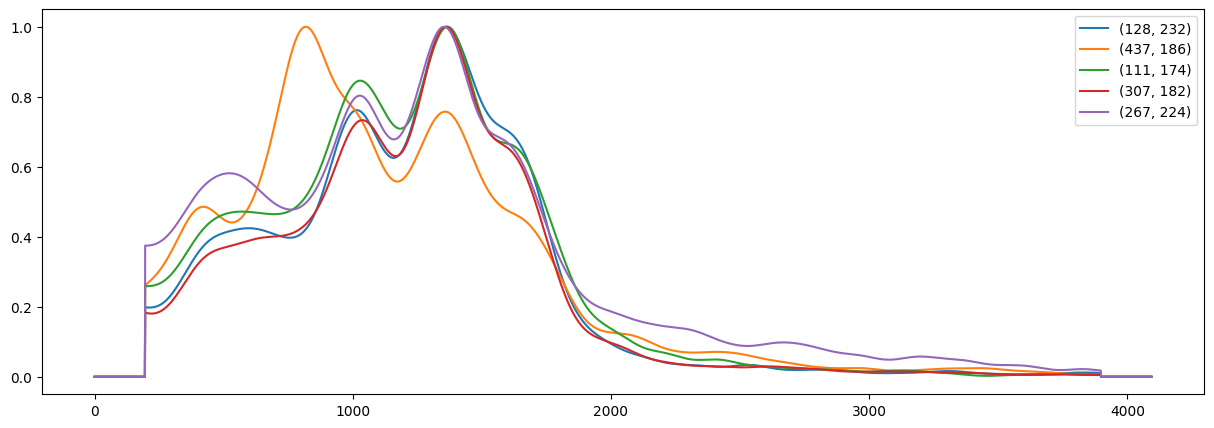

In [4]:
import matplotlib.pyplot as plt
import random 
plt.figure(figsize=(15, 5))
for i in range(5):
    xy = random.randint(0, e_xy_smooth.shape[0]-1), random.randint(0, e_xy_smooth.shape[1]-1)
    print(xy)
    plt.plot(e_xy_smooth[xy], label=str(xy))
plt.legend()

In [5]:
energy_range, e_xy_processed = DataPreprocessor.processed_spectra(e_xy_smooth, peaks, peak_energies)
H, W, C = e_xy_processed.shape

/home/kyre/repos/masters-thesis/src/DataPreprocessor.py:208: RuntimeWarning: Performing pixel-wise extrapolation, which can be slow for large images.
  warnings.warn("Performing pixel-wise extrapolation, which can be slow for large images.", RuntimeWarning)
100%|██████████| 524/524 [01:07<00:00,  7.80it/s]


(42, 242)
(328, 109)
(473, 164)
(131, 50)
(409, 286)


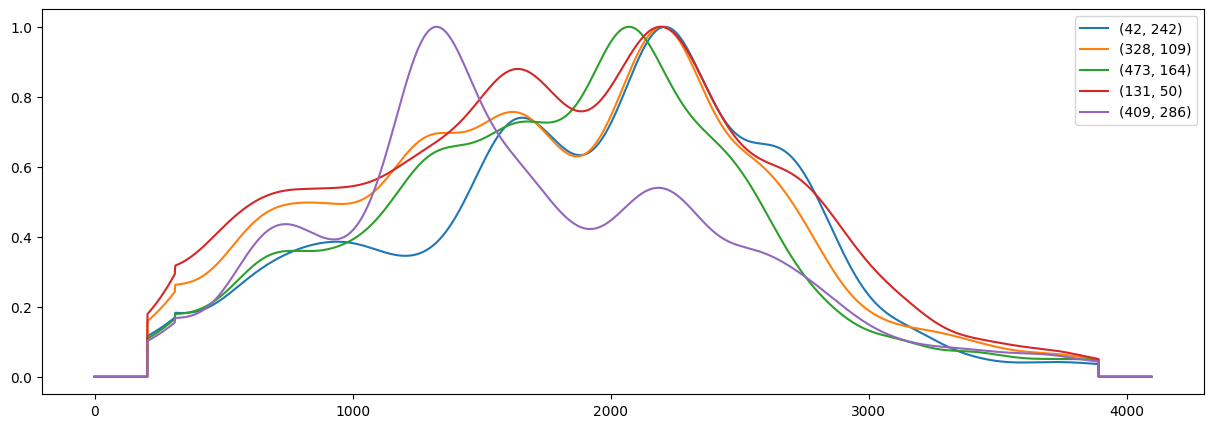

In [6]:
plt.figure(figsize=(15, 5))
for i in range(5):
    xy = random.randint(0, e_xy_processed.shape[0]-1), random.randint(0, e_xy_smooth.shape[1]-1)
    print(xy)
    plt.plot(e_xy_processed[xy], label=str(xy))
plt.legend()

In [7]:
import matplotlib.pyplot as plt

def plot_pad_max_peak_positions(e_xy, object_name):
    peak_map = np.argmax(e_xy, axis=2)

    _, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(peak_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Max peak position")
    plt.title("Max Peak Positions")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    
    plt.savefig(f"data/plots/max_peak_positions{object_name}.svg", bbox_inches='tight',  pad_inches=0)

def plot_pad_photon_counts(e_xy, object_name): 
    photon_count_map = np.sum(e_xy, axis=2)
    photon_count_map /= np.max(photon_count_map)

    _, ax = plt.subplots(figsize=(8, 8))
    plt.title("Relative Photon Counts")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    im = ax.imshow(photon_count_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Relative photon counts")
    
    plt.savefig(f"data/plots/photon_counts{object_name}.svg", bbox_inches='tight',  pad_inches=0)

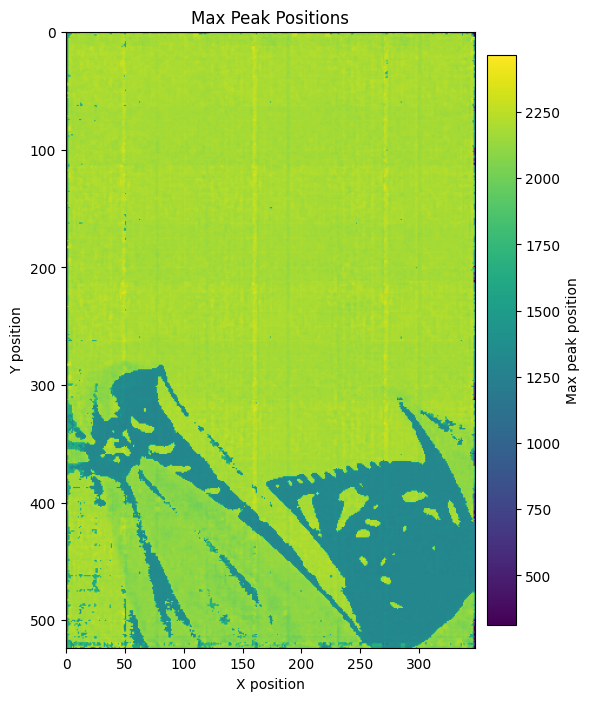

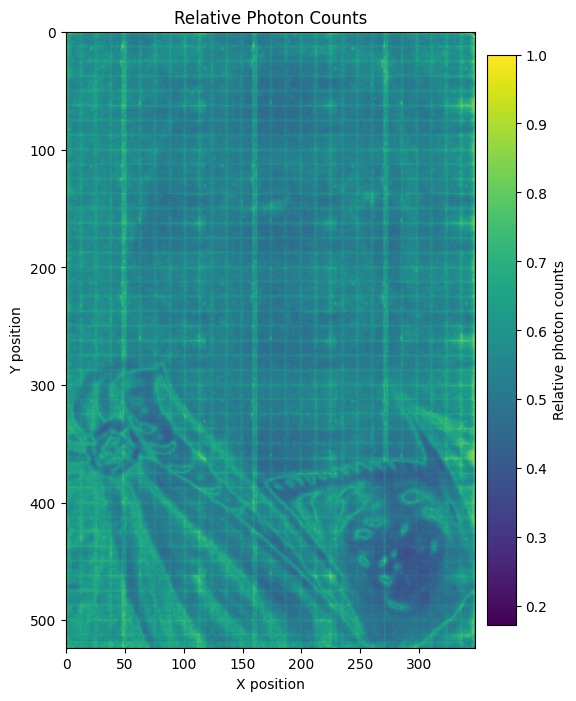

In [8]:
plot_pad_max_peak_positions(e_xy_processed, object_name)
plot_pad_photon_counts(e_xy_processed, object_name)

In [9]:
result = {"e_xy": e_xy_processed, "peaks": peaks, "peak_energies": peak_energies }
np.savez(
    f"data/objects/processed/{object_name}_{patch_size}x{patch_size}_patches.npz", **result
)

Note: `n_components != 2` have not been thoroughly tested.
/tmp/ipykernel_122278/2730019236.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_transformed[:, 0], X_transformed[:, 1], cmap="Spectral", s=0.6)


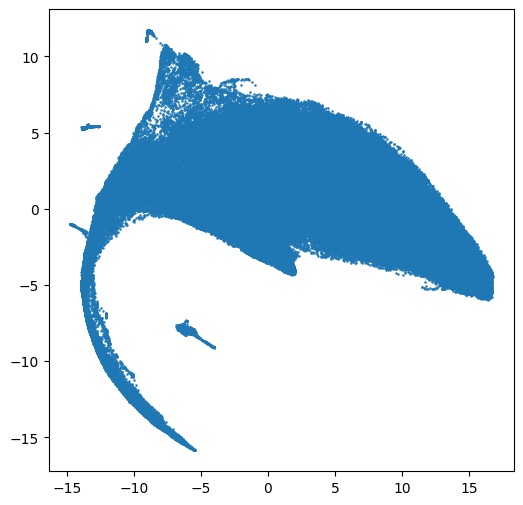

In [10]:
import pacmap
import numpy as np
import matplotlib.pyplot as plt

# loading preprocessed coil_20 dataset
# you can change it with any dataset that is in the ndarray format, with the shape (N, D)
# where N is the number of samples and D is the dimension of each sample
shape = e_xy_processed.shape
X = e_xy_processed.reshape(shape[0] * shape[1], -1)

# initializing the pacmap instance
# Setting n_neighbors to "None" leads to an automatic choice shown below in "parameter" section
embedding = pacmap.PaCMAP(n_components=128, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0) 

# fit the data (The index of transformed data corresponds to the index of the original data)
X_transformed = embedding.fit_transform(X, init="pca")

# visualize the embedding
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], cmap="Spectral", s=0.6)

37
Cluster labels shape: (182352,)
Reshaped cluster image shape: (524, 348)


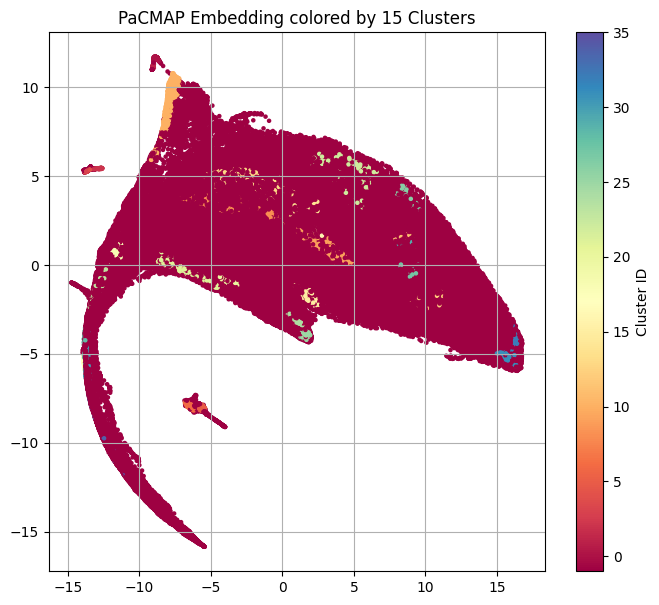

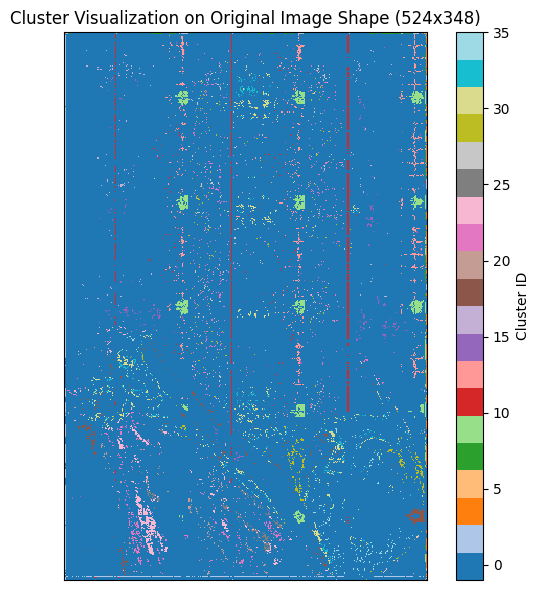

In [11]:
from sklearn.cluster import HDBSCAN
original_shape = e_xy_processed.shape

n_clusters = 15 # You need to decide on this number based on your data

# 2. Apply K-Means clustering
kmeans = HDBSCAN(min_cluster_size=100, max_cluster_size=1000)
cluster_labels = kmeans.fit_predict(X_transformed)
print(np.unique(cluster_labels).shape[0])

print(f"Cluster labels shape: {cluster_labels.shape}")

# ----------------------------------------------------------------------
# Visualizing the clusters
# ----------------------------------------------------------------------

# Visualize the PaCMAP embedding colored by clusters
fig1, ax1 = plt.subplots(1, 1, figsize=(8, 7))
scatter = ax1.scatter(X_transformed[:, 0], X_transformed[:, 1], c=cluster_labels, cmap="Spectral", s=5) # Use 'c' for color
ax1.set_title(f'PaCMAP Embedding colored by {n_clusters} Clusters')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)

# Reshape the cluster labels back to the original image shape
# The order of points in X_transformed corresponds directly to the flattened X,
# which in turn corresponds to the raster scan order of the original image.
cluster_image = cluster_labels.reshape(original_shape[0], original_shape[1])

print(f"Reshaped cluster image shape: {cluster_image.shape}")

# Visualize the cluster image
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 6))
# Use a colormap suitable for discrete values
img = ax2.imshow(cluster_image, cmap='tab20', interpolation='nearest') # 'tab20' or 'viridis' etc.
ax2.set_title(f'Cluster Visualization on Original Image Shape ({original_shape[0]}x{original_shape[1]})')
plt.colorbar(img, label='Cluster ID')
ax2.set_xticks([]) # Hide ticks for image view
ax2.set_yticks([])
plt.tight_layout()

# Display both plots
plt.show()